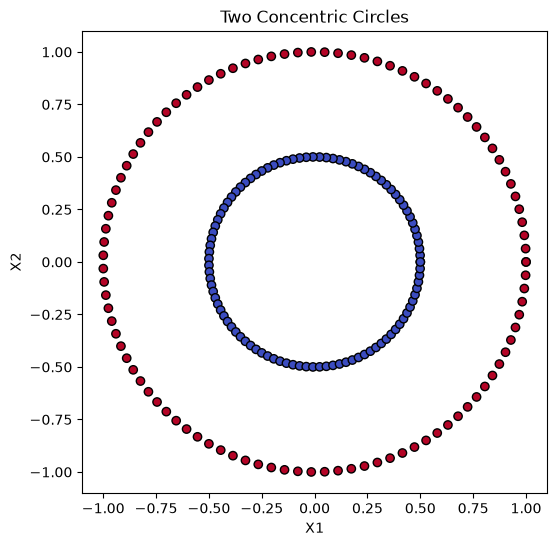

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data: Two concentric circles
np.random.seed(42)
n_samples = 200

# Inner circle (class 0)
theta_inner = np.linspace(0, 2 * np.pi, n_samples // 2)
X_inner = np.c_[np.cos(theta_inner), np.sin(theta_inner)] * 0.5
y_inner = np.zeros(n_samples // 2)

# Outer circle (class 1)
theta_outer = np.linspace(0, 2 * np.pi, n_samples // 2)
X_outer = np.c_[np.cos(theta_outer), np.sin(theta_outer)] * 1.0
y_outer = np.ones(n_samples // 2)

# Combine the datasets
X = np.vstack([X_inner, X_outer])
y = np.hstack([y_inner, y_outer])

# Plot the data
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Two Concentric Circles")
plt.show()

## How a logistic regression classifier can be made to separate these two classes 

I first noticed that a normal logistic regression model would not work with just `X1` and `X2`. It tries to draw a straight line between the classes, but there is no straight line that can separate one circle from another circle around it.

To fix this, I calculated how far each point is from the center. I used the squared radius:

$$r^2 = X1^2 + X2^2$$

Every point on the inner circle has $r^2 = 0.25$, while every point on the outer circle has $r^2 = 1.00$. This gives the model two clearly different values, so it can learn a separation between the inner and outer circles.

##Assement
As we see the accuracy result below, we got 1.0 which means the model performed 100% accuracy. This happens because this dataset is very clean. All points on the inner circle have a smaller squared radius than the points on the outer circle, with no overlap between them. 

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Convert each (X1, X2) point into its squared distance from the center.
X_radius_squared = (X[:, 0]**2 + X[:, 1]**2).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_radius_squared, y.astype(int), test_size=0.25,
    random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 1.0


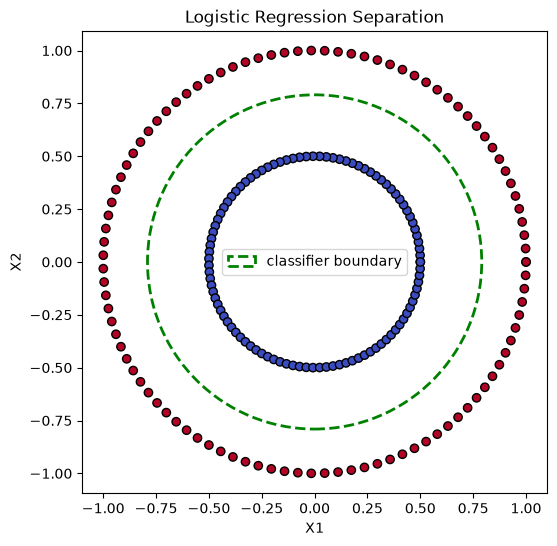

In [ ]:
# convert and plot threshold on circle
r_squared_threshold = -model.intercept_[0] / model.coef_[0, 0]

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
boundary = plt.Circle(
    (0, 0), np.sqrt(r_squared_threshold),
    fill=False, color="green", linestyle="--", linewidth=2,
    label="classifier boundary"
)
plt.gca().add_patch(boundary)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Logistic Regression Separation")
plt.axis("equal")
plt.legend()
plt.show()